### Reading data

In [421]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC

df_real_news = pd.read_csv("real_news.csv")
df_fake_news = pd.read_csv("fake_news.csv")

df_real_news, df_fake_news

(                                                   title  \
 0      As U.S. budget fight looms, Republicans flip t...   
 1      U.S. military to accept transgender recruits o...   
 2      Senior U.S. Republican senator: 'Let Mr. Muell...   
 3      FBI Russia probe helped by Australian diplomat...   
 4      Trump wants Postal Service to charge 'much mor...   
 ...                                                  ...   
 21412  'Fully committed' NATO backs new U.S. approach...   
 21413  LexisNexis withdrew two products from Chinese ...   
 21414  Minsk cultural hub becomes haven from authorities   
 21415  Vatican upbeat on possibility of Pope Francis ...   
 21416  Indonesia to buy $1.14 billion worth of Russia...   
 
                                                     text       subject  \
 0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
 1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
 2      WASHINGTON (Reuters) - The specia

In [422]:
df_fake_news["label"] = "fake"
df_fake_news

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",fake
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",fake
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",fake
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",fake


In [423]:
df_real_news["label"] = "real"
df_real_news

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",real
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",real
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",real
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",real
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",real
...,...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",real
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",real
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",real
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",real


### Concat fake and real news dataframes

In [424]:
df = pd.concat([df_real_news, df_fake_news])
df = df.sort_values(by="title")

In [425]:
df.drop(columns=["date"], inplace=True)

### How the data frame looks like

In [426]:
df

,title,text,subject,label
7786,\r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...,"A 10-year-old girl smacked down Donald Trump, ...",News,fake
1050,\r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...,"At this point, every Republican who refuses to...",News,fake
3930,\r\r\r\r\r\r\r\nTrump Gets STOMPED For Whining...,Donald Trump has been attacking President Obam...,News,fake
1594,\r\r\r\r\r\r\r\nWATCH: Democratic Rep Delivers...,Massachusetts Rep. Jim McGovern brought the Ho...,News,fake
5161,#AfterTrumpImplodes Hashtag Hilariously Imagi...,What will the world be like post-Donald Trump?...,News,fake
...,...,...,...,...
16696,“YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...,"No matter which candidate you support, this mo...",Government News,fake
14235,“YOU’RE HIRED!” Trump Pulls Unemployed Vet Fro...,"No matter which candidate you support, this mo...",politics,fake
11729,“Your rights are NOT superior to mine!” JUDGE ...,,politics,fake
15113,“You’re Not Welcome!” Obama As Welcome At Rose...,Roseberg residents and families of victims are...,politics,fake


In [427]:
df.info()


<class 'pandas.DataFrame'>
Index: 44898 entries, 7786 to 21428
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   label    44898 non-null  str  
dtypes: str(4)
memory usage: 1.7 MB


In [428]:
df.isna().sum()

title      0
text       0
subject    0
label      0
dtype: int64

### Displaying the number of subject with bar chart

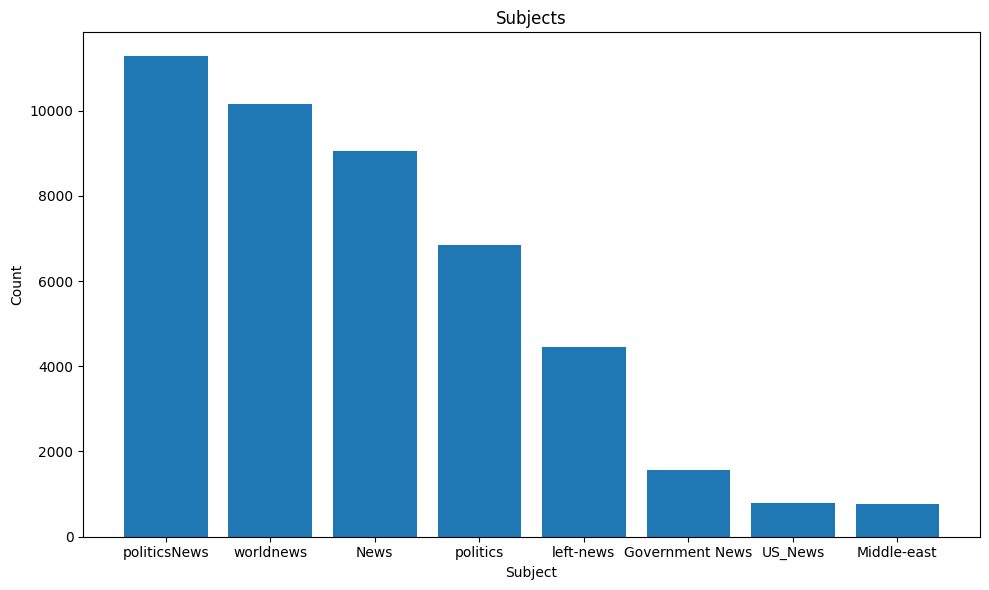

In [429]:
df['subject'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(df['subject'].value_counts().index, df['subject'].value_counts().values)
plt.title('Subjects')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [430]:
df.head()

,title,text,subject,label
7786,\r\r\r\r\r\r\r\nDonald Trump Gets His A** Hand...,"A 10-year-old girl smacked down Donald Trump, ...",News,fake
1050,\r\r\r\r\r\r\r\nEx-GOP Congressman Shreds Fell...,"At this point, every Republican who refuses to...",News,fake
3930,\r\r\r\r\r\r\r\nTrump Gets STOMPED For Whining...,Donald Trump has been attacking President Obam...,News,fake
1594,\r\r\r\r\r\r\r\nWATCH: Democratic Rep Delivers...,Massachusetts Rep. Jim McGovern brought the Ho...,News,fake
5161,#AfterTrumpImplodes Hashtag Hilariously Imagi...,What will the world be like post-Donald Trump?...,News,fake


In [431]:
print(df.iloc[1]["title"])
print(df.iloc[5]["title"])
print(df.iloc[10]["title"])
print(df.iloc[15]["title"])


Ex-GOP Congressman Shreds Fellow Republicans For Not ‘Howling’ For Trump’s Impeachment (VIDEO)

 #BlackLivesMatter Leader To Run For Mayor Of Racially Troubled Baltimore (TWEET)
 #NeverTrump GOP Delegates: Party Brass Intimidating Us Into Supporting Trump (VIDEO)
 #RESISTANCE Organizers Have An AMAZING New Anti-Trump Campaign; Trump Will Be FURIOUS (IMAGES)


In [432]:
def clean_data(text):
    text = str(text).lower()
    text = re.sub(r'\r|\n', ' ', text)
    text = re.sub(r'\s*\([^)]*\)', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    return text.strip()

df['title'] = df['title'].apply(clean_data)
df['text'] = df['text'].apply(clean_data)
df['subject'] = df['subject'].apply(clean_data)


In [433]:
print(df.iloc[1]["title"])
print(df.iloc[5]["title"])
print(df.iloc[10]["title"])
print(df.iloc[15]["title"])

exgop congressman shreds fellow republicans for not ‘howling’ for trump’s impeachment
blacklivesmatter leader to run for mayor of racially troubled baltimore
nevertrump gop delegates party brass intimidating us into supporting trump
resistance organizers have an amazing new antitrump campaign trump will be furious


In [434]:
df.head()

,title,text,subject,label
7786,donald trump gets his a handed to him by a 10y...,a 10yearold girl smacked down donald trump and...,news,fake
1050,exgop congressman shreds fellow republicans fo...,at this point every republican who refuses to ...,news,fake
3930,trump gets stomped for whining about president...,donald trump has been attacking president obam...,news,fake
1594,watch democratic rep delivers scathing rebuke ...,massachusetts rep jim mcgovern brought the hou...,news,fake
5161,aftertrumpimplodes hashtag hilariously imagine...,what will the world be like postdonald trump a...,news,fake


### Data fitting and transforming

In [435]:
y = df["label"]
x = df['title'] + " " + df['text'] + " " + df['subject']


In [436]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y.shape

(44898,)

In [437]:
# tfidf = TfidfVectorizer(stop_words='english')
# x = tfidf.fit_transform(x)

In [438]:
# x.shape

## Split and Fit Data


In [439]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1307)

# Logistic Regression


#### PIPELINE - Combine Techniques

In [440]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english')),
    ("lr", LogisticRegression()),
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('gbc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [441]:
y_pred = pipeline.predict(x_test)

In [442]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4734
           1       0.98      0.99      0.99      4246

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### Confusion Matrix for Logistic Regression


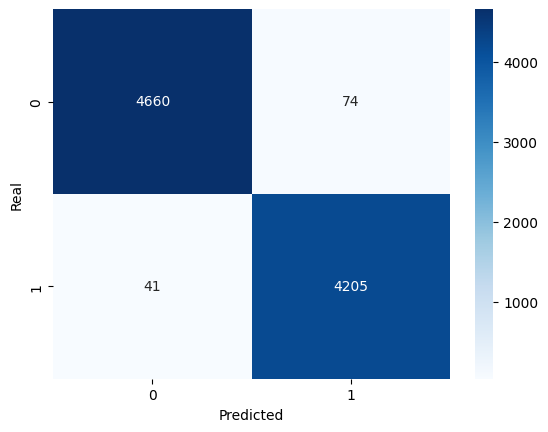

In [443]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.show()

# LinearSVC

#### PIPELINE - Combine Techniques

In [444]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words='english')),
    ("lsvc", LinearSVC()),
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('gbc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [445]:
y_pred = pipeline.predict(x_test)

In [446]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4734
           1       0.99      1.00      1.00      4246

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



### Confusion Matrix for LinearSVC

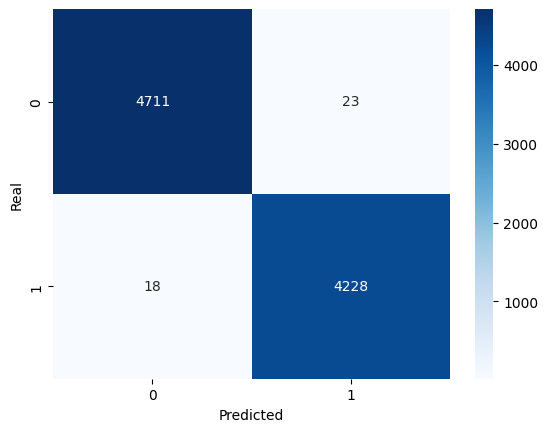

In [447]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Real')
plt.show()